In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# **Task 1 Dataset Understanding**

In [2]:
customer = pd.read_csv("/content/customer_churn_nn.csv")

In [3]:
customer.shape

(2000, 17)

In [4]:
print("Target Variable: churn")
print("0 = Customer stays")
print("1 = Customer leaves")

Target Variable: churn
0 = Customer stays
1 = Customer leaves


In [5]:
customer.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [6]:
customer.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [7]:
y = customer['churn']

print(y.value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


# **Task 2 Data Preprocessing**

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [9]:
customer = customer.drop('customer_id', axis =1)

In [10]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

label_encoder = LabelEncoder()

for col in categorical_cols:
    customer[col] = label_encoder.fit_transform(customer[col])

In [11]:
X = customer.drop('churn', axis= 1)
y = customer['churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42)

In [13]:
print("Training Shape: ", X_train.shape)
print("Testing Shape: ", X_test.shape)

Training Shape:  (1600, 15)
Testing Shape:  (400, 15)


# **Task 3 Neural Network Model Building**

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

# **Task 4 Training and Evaluation**


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

In [17]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9672 - loss: 0.2971 - val_accuracy: 0.9781 - val_loss: 0.1334
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0869 - val_accuracy: 0.9781 - val_loss: 0.1007
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0699 - val_accuracy: 0.9781 - val_loss: 0.0988
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0642 - val_accuracy: 0.9781 - val_loss: 0.0959
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0604 - val_accuracy: 0.9781 - val_loss: 0.0945
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0569 - val_accuracy: 0.9781 - val_loss: 0.0938
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0539 - val_accuracy: 0.9781 - val_loss: 0.0939
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0511 - val_accuracy: 0.9781 - val_loss

In [18]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0763  
Test Loss: 0.0763
Test Accuracy: 0.9825


In [19]:
# Training accuracy and loss
train_accuracy = history.history['accuracy']
train_loss = history.history['loss']

print(train_accuracy)
print(train_loss)

# Testing accuracy and loss
test_accuracy = history.history['val_accuracy']
test_loss = history.history['val_loss']

print(test_accuracy)
print(test_loss)

[0.9671875238418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579, 0.9867187738418579]
[0.2970516085624695, 0.08688315749168396, 0.06986032426357269, 0.06424407660961151, 0.0604194812476635, 0.05690081790089607, 0.0538971945643425, 0.051097940653562546, 0.04893394559621811, 0.0468081459403038]
[0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421, 0.9781249761581421]
[0.1334119737148285, 0.1007191389799118, 0.0987728014588356, 0.09586052596569061, 0.0945068746805191, 0.09376940876245499, 0.09390782564878464, 0.09468664228916168, 0.09453804790973663, 0.09527119994163513]


In [20]:
# Confusion matrix
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(cm)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[393   0]
 [  7   0]]


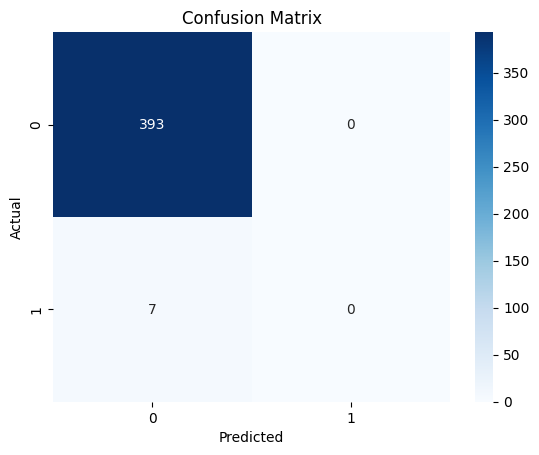

In [21]:
# Visualisation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Task 5 Hyperparameter Experimentation**

In [23]:
from tensorflow.keras.optimizers import Adam

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Funtion to build model
def create_model(hidden1, hidden2, activation, learning_rate, input_dim):
    model = Sequential()
    model.add(Dense(hidden1, activation=activation, input_dim=input_dim))
    model.add(Dense(hidden2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Experiment Configurations
experiment_configs = [
    {'hidden1': 64, 'hidden2': 32, 'activation': 'relu', 'learning_rate': 0.001, 'batch_size': 16, 'epochs': 25},
    {'hidden1': 128, 'hidden2': 64, 'activation': 'sigmoid', 'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 25},
    {'hidden1': 64, 'hidden2': 32, 'activation': 'tanh', 'learning_rate': 0.0005,  'batch_size': 32, 'epochs': 30}]

# Run Experiments
results= []
for i, exp in enumerate(experiment_configs):
    print(f"Experiment {i+1}:")
    # Create the model using parameters from the current experiment
    model = create_model(exp['hidden1'], exp['hidden2'], exp['activation'], exp['learning_rate'], X_train.shape[1])
    # Train the model using training parameters from the current experiment
    history = model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch_size'], validation_split=0.2, verbose=0)

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Store Result
    results.append({'hidden1': exp['hidden1'], 'hidden2': exp['hidden2'], 'activation': exp['activation'], 'learning_rate': exp['learning_rate'], 'test_accuracy': test_accuracy, 'Test Loss': round(test_loss, 4), 'batch_size': exp['batch_size'], 'epochs': exp['epochs']})

# Comparison Table
results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1:
Experiment 2:
Experiment 3:
   hidden1  hidden2 activation  learning_rate  test_accuracy  Test Loss  \
0       64       32       relu         0.0010         0.9825     0.1461   
1      128       64    sigmoid         0.0001         0.9825     0.0847   
2       64       32       tanh         0.0005         0.9825     0.0708   

   batch_size  epochs  
0          16      25  
1          16      25  
2          32      30  


# **Task 6 Final Reflection**


# What role do weights and biases play in the model?
Weights and biases are the main parameters that help a neural network learn patterns from data.

**Weights:**

It determines the importance of each input features. Larger weights mean the feature has a stronger influence on the prediction.

**Biases:**

It helps shift the output of the neuron, allowing the model to fit the data more accurately even when input values are zero.

# Why is an activation function required?

An activation function introduces non-linearity into the neural network. Without it, the model would behave like a simple linear equation and would not be able to learn complex patterns.

# What happens when learning rate is too high or too low?

**Learning rate too high:**

The model updates weights too aggressively, causing it to overshoot the optimal solution.

**Learning rate too low:**

The model learns very slowly and takes a long time to reach the optimal solution.

# Did your model show signs of underfitting or overfitting? Explain.

My model shows overfitting if the training accuracy became much higher than the validation/testing accuracy. This means the neural network learned the training data very well but could not generalize properly to unseen data.

